In [1]:
# improve hierararchy of distance matrix
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn
import sys
sys.path.append('../')
import MHMDS.embed_funs as emb
import cmdstanpy as stan
from scipy import stats
import pickle
# from sklearn.decomposition import PCA
from sklearn.manifold import MDS
import MHMDS.quality_metrics as qms
import MHMDS.large_scale_hmds as lhmds

In [2]:
# load metadata and embeded data
metadata = pd.read_csv('../data/metadata/Celegans_PCA100_metadata.csv')
alllocs = np.loadtxt('../MultiscalehMDS_feature/result/FeatMat_Celegans_PCA100/cls_800_100_Nn_30,10_Nd_3_min_3_max_400_corr_0_coords_85333.txt')

In [3]:
# inds
inds = np.loadtxt('../MultiscalehMDS_feature/result/FeatMat_Celegans_PCA100/cls_800_100_Nn_30,10_Nd_3_min_3_max_400_corr_0_inds_after_prep.txt')
alllocs = alllocs[np.argsort(inds)]

In [4]:
# visulize 3-d embedding
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import plotly.colors

In [5]:
meta_d = metadata.iloc[:,1:]
meta_d.reset_index(inplace=True)

In [6]:
native3d = emb.to_native(alllocs)
radii = np.linalg.norm(native3d,axis=1)

df_toplot = pd.concat([meta_d,pd.DataFrame({'x':native3d[:,0],
                                             'y':native3d[:,1],
                                            'z':native3d[:,2],
                                           'radii':radii})],axis=1)

In [ ]:

fig = px.scatter_3d(df_toplot , x='x', y='y', z='z',
                   color='cell.type', opacity=1,size='radii',size_max=15,)
fig.show()

In [8]:
data_recenter = emb.perform_recenter(alllocs,np.arange(len(alllocs)))

18:06:54 - cmdstanpy - INFO - Chain [1] start processing
18:06:54 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
# cell types: regroup
toplot = metadata.groupby('cell.type').count().iloc[:,1].sort_values(ascending=False)[:15].index

In [ ]:
nativerc = emb.to_native(data_recenter)
radii_rc = np.linalg.norm(nativerc,axis=1)

df_toplot = pd.concat([meta_d,pd.DataFrame({'x':nativerc[:,0],
                                             'y':nativerc[:,1],
                                             'z':nativerc[:,2],
                                           'radii':radii_rc,
                                           'scale':np.ones_like(radii_rc)})],axis=1)
df_toplot['cell.type'][pd.isna(df_toplot['cell.type'])]='Unannotated'

fig = px.scatter_3d(df_toplot[np.isin(df_toplot['cell.type'],toplot)] , x='x', y='y', z='z',
                   color='cell.type', opacity=1,size='scale',size_max=15,)

fig.show()
# fig.write_html('Celegans_80k_3d_celltype.html')

In [ ]:
nativerc = emb.to_native(data_recenter)
radii_rc = np.linalg.norm(nativerc,axis=1)

df_toplot = pd.concat([meta_d,pd.DataFrame({'x':nativerc[:,0],
                                             'y':nativerc[:,1],
                                             'z':nativerc[:,2],
                                           'radii':radii_rc,
                                           'scale':np.ones_like(radii_rc)})],axis=1)
df_toplot['cell.type'][pd.isna(df_toplot['cell.type'])]='Unannotated'

fig = px.scatter_3d(df_toplot , x='x', y='y', z='z',
                   color='embryo.time', opacity=1,size='scale',size_max=15,
                    color_continuous_scale = plotly.colors.diverging.Spectral)

fig.show()
# fig.write_html('Celegans_80k_3d_embryotime.html')

In [11]:
lplot = ['< 100','100-130','130-170','170-210','210-270','270-330','330-390',
         '390-450','450-510','510-580','580-650','> 650']
xx = []
means = []
for ind in lplot[:-1]:
    means.append(np.mean(df_toplot[df_toplot['embryo.time.bin'] == ind]['radii']))
    xx.append(np.mean(df_toplot[df_toplot['embryo.time.bin'] == ind]['embryo.time']))

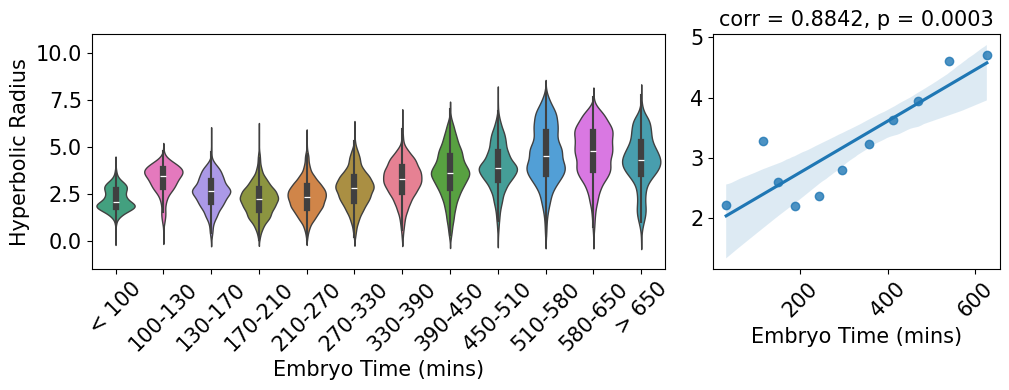

In [12]:
# radius versus embryotime
fig,axs = plt.subplots(1,2,figsize = (10,4),gridspec_kw={'width_ratios': [2,1]})
axs = axs.flatten()
sn.violinplot(data=df_toplot[np.isin(df_toplot['embryo.time.bin'], lplot)],x='embryo.time.bin',
              y='radii',order=lplot,hue='embryo.time.bin',ax = axs[0],linewidth=1)

# axs[1].plot(xx,mean_poin,'ko')
sn.regplot(data=pd.DataFrame({'x':xx,'y':means}),x='x',y='y',ax=axs[1])
corr,p  = stats.pearsonr(xx,means)
axs[1].set_title('corr = %.4f, p = %.4f'%(corr,p),fontsize=15)

for i in [0,1]:
    axs[i].set_xlabel('Embryo Time (mins)',fontsize=15)
    axs[i].set_ylabel('',fontsize=15)
    axs[i].tick_params(axis='x', labelsize=15,rotation=45)
    axs[i].tick_params(axis="y", labelsize=15)
    
for i in [0]:
    axs[i].set_ylim([-1.5,11])
    axs[i].set_ylabel('Hyperbolic Radius',fontsize=15)
    

plt.tight_layout()